In this notebook, we load the preprocessed dataset and define a set of candidate classifiers (Logistic Regression, Gaussian Naive Bayes, Linear Discriminant Analysis, Support Vector Machine, Random Forest, and LightGBM).

We implement a repeated nested cross-validation (rnCV) strategy with:
- **10 repetitions (rounds)**
- **5-fold outer loop** for generalization estimation
- **3-fold inner loop** for hyperparameter tuning

The nestedCV logic can be seen drawn in nestedCV_logic.pdf

During tuning, we optimize models based on **F1 score**, which balances false positives and false negatives — important due to moderate class imbalance that we saw during EDA.

In the case of LGBM there was a warning that could not be supressed despite all tries but it can be safely scrolled down.

After rnCV, we:
- Compute performance metrics (F1, AUC, MCC, Precision, Recall, etc.) for each classifier across the test folds
- Rank classifiers using **median scores**
- Apply **bootstrap resampling** to calculate 95% confidence intervals (CIs)
- Use both medians and CIs to identify the best-performing model

Finally, we
- Re-tune the best model (Logistic Regression) using 5-fold CV on the full dataset
- Train it on the entire dataset with optimal hyperparameters
- Save the trained model to a `.pkl` file called final_model.pkl for deployment


In [1]:
import sys
import os
sys.path.append(os.path.abspath("/Users/vashqu/Desktop/Assignment-2/src"))
from src import *
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns




In [76]:
models = {
    'LR': LogisticRegression(solver='saga', max_iter=10000),
    'GNB': GaussianNB(),
    'LDA': LinearDiscriminantAnalysis(),
    'SVM': SVC(probability=True),
    'RF': RandomForestClassifier(),
    'LGBM': LGBMClassifier(verbose=-1)
}


In [77]:
param_grids = {
    'LR': {
        'model__C': [0.01, 0.1, 1],
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__penalty': ['elasticnet']
    },
    'GNB': {},  # no tunable hyperparameters
    'LDA': {
        'model__solver': ['svd', 'lsqr', 'eigen']
    },
    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf'],
        'model__gamma': ['scale', 'auto']
    },
    'RF': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [5, 10, None],
        'model__min_samples_split': [2, 5]
    },
    'LGBM': {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1],
        'model__num_leaves': [15, 31]
    }
}


In [ ]:

df = pd.read_csv('/Users/vashqu/Desktop/Assignment-2/data/breast_cancer_clean.csv')

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,14.68,20.13,94.74,684.5,0.09867,0.07200,0.07395,0.05259,0.1586,...,19.07,30.88,123.40,1138.0,0.1464,0.1871,0.29140,0.16090,0.3029,0.08216
1,0,11.50,18.45,73.28,407.4,0.09345,0.05991,0.02638,0.02069,0.1834,...,12.97,22.46,83.12,508.9,0.1183,0.1049,0.08105,0.06544,0.2740,NaN
2,1,15.85,23.95,103.70,782.7,0.08401,0.10020,0.09938,0.05364,0.1847,...,16.84,27.66,112.00,876.5,0.1131,0.1924,0.23220,0.11190,0.2809,0.06287
3,1,18.82,21.97,123.70,1110.0,0.10180,0.13890,0.15940,0.08744,0.1943,...,22.66,30.93,145.30,1603.0,0.1390,0.3463,0.39120,0.17080,0.3007,0.08314
4,0,12.95,16.02,83.14,513.7,0.10050,0.07943,0.06155,0.03370,0.1730,...,13.74,19.93,88.81,585.4,0.1483,NaN,0.22410,0.10560,0.3380,0.09584


In [79]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

rncv = RepeatedNestedCV(X, y, models, param_grids, scoring = 'f1')
rncv.run()

Running LR on fold 1 of repeat 1
Running LR on fold 2 of repeat 1
Running LR on fold 3 of repeat 1
Running LR on fold 4 of repeat 1
Running LR on fold 5 of repeat 1
Running LR on fold 1 of repeat 2
Running LR on fold 2 of repeat 2
Running LR on fold 3 of repeat 2
Running LR on fold 4 of repeat 2
Running LR on fold 5 of repeat 2
Running LR on fold 1 of repeat 3
Running LR on fold 2 of repeat 3
Running LR on fold 3 of repeat 3
Running LR on fold 4 of repeat 3
Running LR on fold 5 of repeat 3
Running LR on fold 1 of repeat 4
Running LR on fold 2 of repeat 4
Running LR on fold 3 of repeat 4
Running LR on fold 4 of repeat 4
Running LR on fold 5 of repeat 4
Running LR on fold 1 of repeat 5
Running LR on fold 2 of repeat 5
Running LR on fold 3 of repeat 5
Running LR on fold 4 of repeat 5
Running LR on fold 5 of repeat 5
Running LR on fold 1 of repeat 6
Running LR on fold 2 of repeat 6
Running LR on fold 3 of repeat 6
Running LR on fold 4 of repeat 6
Running LR on fold 5 of repeat 6
Running LR

/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

Running LGBM on fold 2 of repeat 1


/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

Running LGBM on fold 3 of repeat 1


...

/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

Running LGBM on fold 4 of repeat 10


/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

Running LGBM on fold 5 of repeat 10


/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ML_Test/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted w

In [80]:
df = rncv.get_results(summary=False)
df.head()

,repeat,fold,model,params,f1_score,accuracy,precision,recall,auc,mcc,balanced_accuracy,specificity,sensitivity,npv,prauc
0,0,0,LR,"{'model__C': 1, 'model__l1_ratio': 0.2, 'model...",0.987342,0.990291,0.975000,1.000000,0.999599,0.979676,0.992188,0.984375,1.000000,1.000000,0.999359
1,0,1,LR,"{'model__C': 1, 'model__l1_ratio': 0.2, 'model...",0.944444,0.961165,1.000000,0.894737,0.991498,0.918078,0.947368,1.000000,0.894737,0.942029,0.987349
2,0,2,LR,"{'model__C': 1, 'model__l1_ratio': 0.2, 'model...",0.961039,0.970588,0.948718,0.973684,0.998766,0.937627,0.971217,0.968750,0.973684,0.984127,0.997992
3,0,3,LR,"{'model__C': 1, 'model__l1_ratio': 0.8, 'model...",0.972973,0.980392,1.000000,0.947368,0.989309,0.958468,0.973684,1.000000,0.947368,0.969697,0.986717
4,0,4,LR,"{'model__C': 1, 'model__l1_ratio': 0.2, 'model...",0.944444,0.960784,1.000000,0.894737,0.983553,0.917663,0.947368,1.000000,0.894737,0.941176,0.985979


In [81]:
metric_cols = ['f1_score', 'accuracy', 'precision', 'recall', 'auc', 'mcc',
               'balanced_accuracy', 'specificity', 'sensitivity', 'npv', 'prauc']

median_df = df.groupby('model')[metric_cols].median()

median_df_sorted = median_df.sort_values(by='mcc', ascending=False)

median_df_sorted

,f1_score,accuracy,precision,recall,auc,mcc,balanced_accuracy,specificity,sensitivity,npv,prauc
model,,,,,,,,,,,
LR,0.960519,0.970731,0.974359,0.947368,0.995920,0.938295,0.968544,0.984615,0.947368,0.969464,0.994171
SVM,0.960000,0.970588,0.973684,0.947368,0.996175,0.937469,0.965872,0.984615,0.947368,0.969231,0.994546
LGBM,0.945946,0.960784,0.971429,0.921053,0.992493,0.916036,0.952714,0.984375,0.921053,0.954545,0.989330
LDA,0.931507,0.951456,1.000000,0.894737,0.992804,0.898613,0.939556,1.000000,0.894737,0.940299,0.989702
RF,0.935887,0.951456,0.948043,0.923077,0.989515,0.897023,0.950427,0.968750,0.923077,0.955553,0.984935
GNB,0.905388,0.931373,0.941176,0.894737,0.987459,0.854147,0.923931,0.968750,0.894737,0.938928,0.981796


## Model Performance Evaluation Across Repeated Nested CV

After running 10 rounds of repeated nested cross-validation (rnCV), we collected the test set results for each model across all 50 outer folds (10 × 5).

Each row in the resulting dataframe corresponds to a specific `(repeat, fold, model)` combination and includes:
- Tuned hyperparameters used
- Multiple evaluation metrics:
  - Classification scores: `f1_score`, `accuracy`, `precision`, `recall`
  - Imbalance-aware metrics: `mcc`, `balanced_accuracy`, `specificity`, `sensitivity`, `npv`, `auc`, `prauc`

This allowed us to robustly estimate model performance using **median metric values** across all test folds.

### Ranking Strategy

We computed the **median value** of each metric for every model, then ranked the models by **Matthews Correlation Coefficient (MCC)** — a robust metric for imbalanced classification problems.

- Unlike accuracy or F1, MCC considers all cells of the confusion matrix.
- It is especially reliable when class sizes are unequal.

### Results Summary

- **Top-performing models** by MCC were:
  1. **Logistic Regression (ElasticNet)** — MCC: ~0.938
  2. **SVM** — MCC: ~0.937
  3. **LightGBM** — MCC: ~0.916

These results suggest that **regularized linear models** and **nonlinear kernel models** both offer strong performance.

We now proceed to:
1. Use **bootstrap resampling** to compute **confidence intervals (CIs)** for the top models
2. Statistically compare their performance to select a final model for deployment


In [ ]:

top_models = ['LR', 'SVM', 'LGBM']
metrics = ['mcc', 'auc', 'f1_score']

bstrap = Bootstrapper(df, models=top_models, metrics=metrics)
ci_summary = bstrap.compute()


In [23]:
ci_summary

,model,metric,median,lower_bound,upper_bound
0,LGBM,mcc,0.916036,0.896654,0.927378
1,LGBM,auc,0.992493,0.988691,0.995978
2,LGBM,f1_score,0.945946,0.933333,0.948828
3,LR,mcc,0.938295,0.937293,0.958300
4,LR,auc,0.995920,0.993010,0.997533
5,LR,f1_score,0.960519,0.960000,0.972973
6,SVM,mcc,0.937469,0.936959,0.958059
7,SVM,auc,0.996175,0.993880,0.997364
8,SVM,f1_score,0.960000,0.958904,0.972973


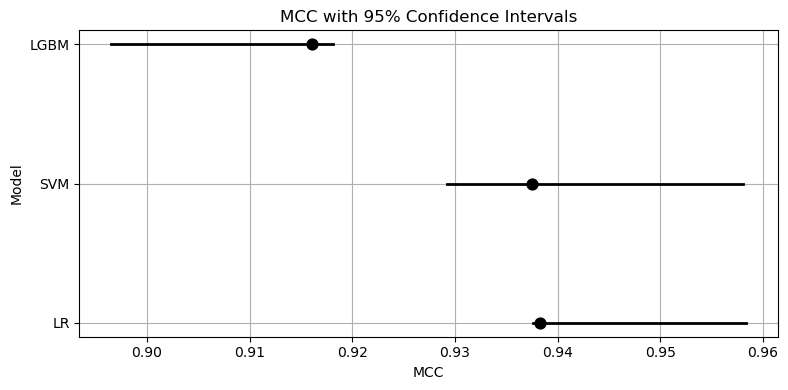

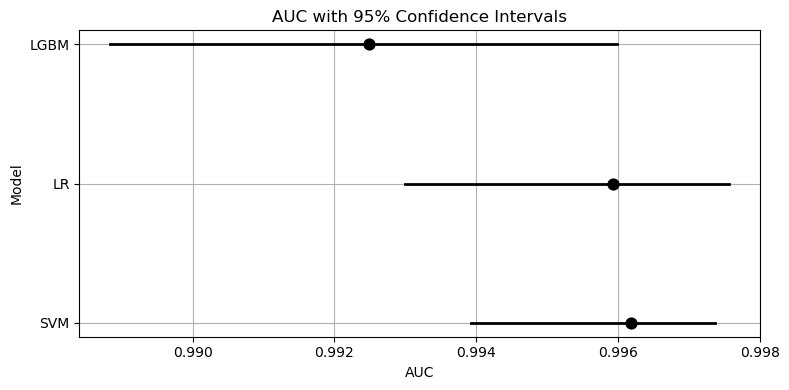

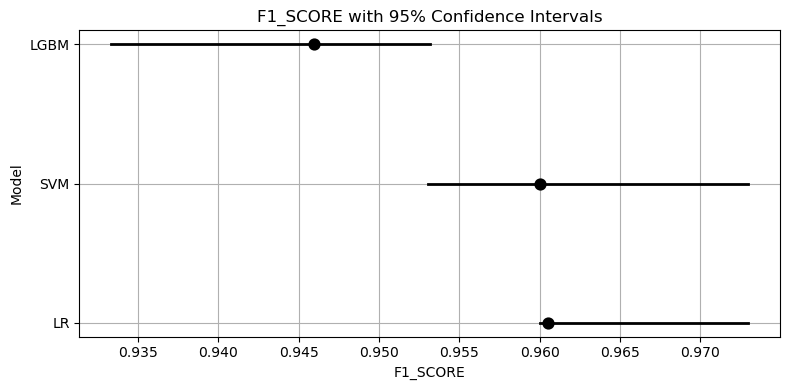

In [ ]:

plot_ci_bars(ci_summary, 'mcc')
plot_ci_bars(ci_summary, 'auc')
plot_ci_bars(ci_summary, 'f1_score')



- **SVM and Logistic Regression** exhibit nearly identical performance across all metrics, with overlapping confidence intervals.
- **LightGBM**, while competitive, shows slightly lower MCC and F1 score, with CIs that are **disjoint or marginally lower** in several metrics.
- These plots confirm that **Logistic Regression** is not only performant but also **more stable**, with a slightly tighter CI across metrics.

### Final Decision

Given the:
- Strong performance (high MCC, F1, and AUC)
- Robustness to variance (tight bootstrap intervals)
- Interpretability of feature coefficients in LR and simplicity for deployment

We selected **Logistic Regression with ElasticNet** as the final model for deployment.

Next, we:
1. Tune the model on the full dataset using CV(5)
2. Train the final instance with optimal hyperparameters
3. Save the trained model as a `.pkl` file for future inference


In [ ]:
trainer = FinalModelTrainer(model_dir="/Users/vashqu/Desktop/Assignment-2/models")
model = trainer.train(X, y, scoring='f1')
trainer.save_model()


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Params: {'model__C': 1, 'model__l1_ratio': 0.2}
Best Score: 0.9620485190105444
Model saved to /Users/vashqu/Desktop/Assignment-2/models/final_model.pkl


We used **F1 score** as the optimization metric.
Selected the best hyperparameter combination:
   - `C = 1`
   - `l1_ratio = 0.2`

The final model was trained and saved in /models


In [ ]:

model = joblib.load('/Users/vashqu/Desktop/Assignment-2/models/final_model.pkl')
coef = model.named_steps['model'].coef_.flatten()

feature_names = X.columns


coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coef,
    'abs_coeff': np.abs(coef)
}).sort_values(by='abs_coeff', ascending=False)

# View top features
coef_df.head(10)


,feature,coefficient,abs_coeff
21,texture_worst,1.445625,1.445625
13,area_se,1.315730,1.315730
23,area_worst,1.142091,1.142091
7,concave points_mean,1.025927,1.025927
28,symmetry_worst,1.021149,1.021149
15,compactness_se,-1.017221,1.017221
26,concavity_worst,0.957388,0.957388
20,radius_worst,0.869858,0.869858
27,concave points_worst,0.847625,0.847625
10,radius_se,0.825013,0.825013


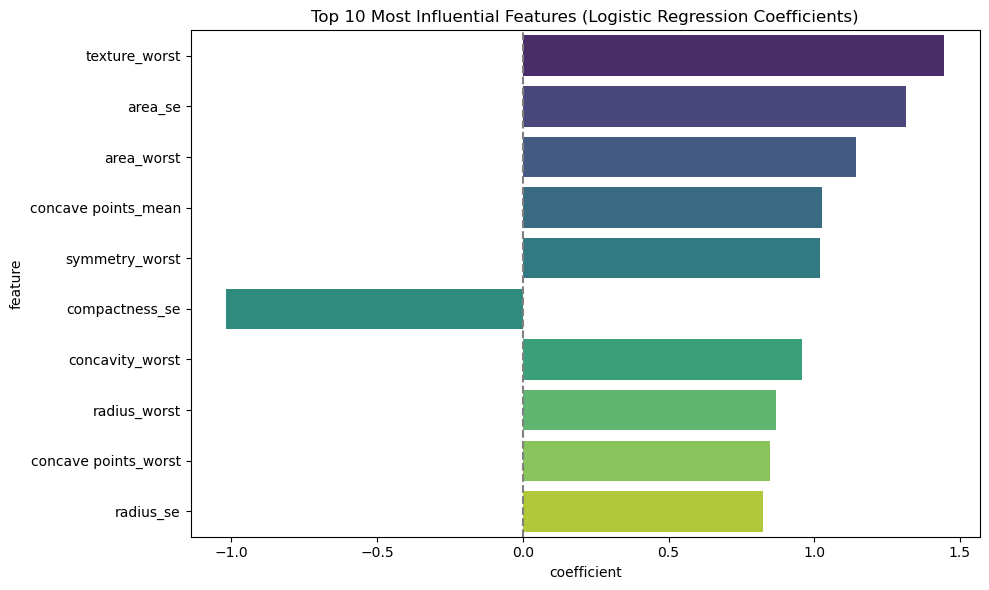

In [ ]:

top_n = 10
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df.head(top_n),
    y='feature',
    x='coefficient',
    palette='viridis'
)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Top 10 Most Influential Features (Logistic Regression Coefficients)')
plt.tight_layout()
plt.show()



One of the strengths of **Logistic Regression** is that we can understand how each feature affects the model’s decision.

We looked at the **coefficients** of the final trained model to see which features had the biggest impact on predicting whether a tumor is malignant.

- **Most important positive features**:
  - `texture_worst`, `area_se`, and `area_worst` had the **largest positive coefficients**.
  - This means that when these values are high, the model is more likely to classify the tumor as **malignant**.
  - These features relate to how large or uneven the tumor cell nuclei are — which often indicates cancer.

- **Most important negative feature**:
  - `compactness_se` had a **negative coefficient**.
  - This suggests that lower variation in compactness (how tight the shape is) might be linked to malignancy in this dataset.

Because we can read and interpret these weights, **Logistic Regression doesn’t just perform well — it also gives us insight into what the model is learning**, which is especially useful in fields like medicine.

